In [109]:
# Importación de las librerías + declaración variables globales
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing   import StandardScaler
import seaborn as sns
from sklearn.linear_model     import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from scipy.stats import f
from sklearn.metrics         import accuracy_score


RANDOM_STATE=42

# lista con las variables más predictivas propuestas por Nando
winner_var_list = ["OverallQual","GrLivArea","TotalBsmtSF","GarageCars","YearBuilt","Neighborhood","BsmtQual","KitchenQual"]

# Lista con todas las variables categóricas que si tienen NA, indican algo diferente a valor faltante
filter_meaning = ["Alley", "BsmtQual", "BsmtCond","BsmtExposure",
                  "BsmtFinType1","BsmtFinType2","FireplaceQu",
                  "GarageType","GarageFinish","GarageQual","GarageCond",
                  "PoolQC","Fence","MiscFeature"]

In [43]:
# Carga de datos
dataset_df = pd.read_csv("data/train.csv")
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


# FASE A - Análisis Exploratorio (EDA)

## Identificación de NaN
Cuidado con el valor NA. Para algunas variables indican que no tienen x cosa,
    no que falte el dato.

In [44]:
dataset_df[winner_var_list].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   OverallQual   1460 non-null   int64
 1   GrLivArea     1460 non-null   int64
 2   TotalBsmtSF   1460 non-null   int64
 3   GarageCars    1460 non-null   int64
 4   YearBuilt     1460 non-null   int64
 5   Neighborhood  1460 non-null   str  
 6   BsmtQual      1423 non-null   str  
 7   KitchenQual   1460 non-null   str  
dtypes: int64(5), str(3)
memory usage: 91.4 KB


In [45]:
dataset_df[winner_var_list].head()

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,Neighborhood,BsmtQual,KitchenQual
0,7,1710,856,2,2003,CollgCr,Gd,Gd
1,6,1262,1262,2,1976,Veenker,Gd,TA
2,7,1786,920,2,2001,CollgCr,Gd,Gd
3,7,1717,756,3,1915,Crawfor,TA,Gd
4,8,2198,1145,3,2000,NoRidge,Gd,Gd


In [46]:
# Observación de las variables categóricas con NA, que implican valores faltantes
na_serie = dataset_df[winner_var_list].isna().sum()
na_serie[na_serie>0].drop(index=filter_meaning, errors = "ignore")

Series([], dtype: int64)

In [47]:
# Obtención de los nombres de las variables categóricas con NA, que implican valores faltantes
columns_index_with_na = na_serie[na_serie>0].drop(index=filter_meaning, errors = "ignore").index
columns_index_with_na

Index([], dtype='str')

##### Diego:
En su momento sacamos como debemos cambiar estas variables (clica dos veces para ver mejor):
LotFrontage    259
MasVnrType     872
MasVnrArea       8
Electrical       1
GarageYrBlt     81
dtype: int64

## Precio

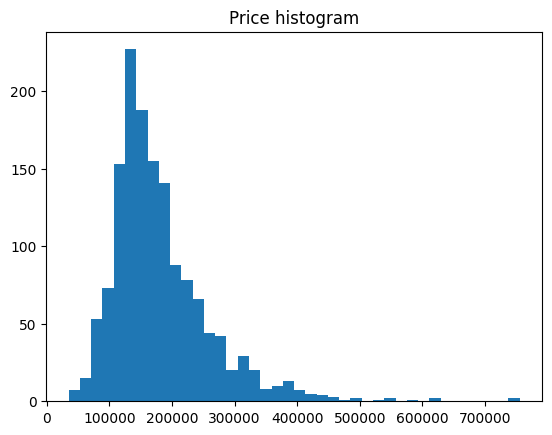

In [48]:
plt.hist(dataset_df["SalePrice"], bins = 40)
plt.title("Price histogram")
plt.show()

# Es necesario normalizar la variable objetivo

## Observación de variables a utilizar en el modelo


### Las variables a utilizar en este modelo son:
    "OverallQual" : Variable numérica discreta del 1 al 10
    "GrLivArea" : Variable numérica continua
    "TotalBsmtSF" : Variable numérica continua
    "GarageCars" : Variable numérica discreta
    "YearBuilt" : Variable numérica discreta
    "Neighborhood" : Variable categórica nominal
    "BsmtQual" : Variable categórica ordinal
    "KitchenQual" : Variable categórica ordinal

In [49]:
df = dataset_df.copy()
df['BsmtQual'] = df['BsmtQual'].fillna('NB')

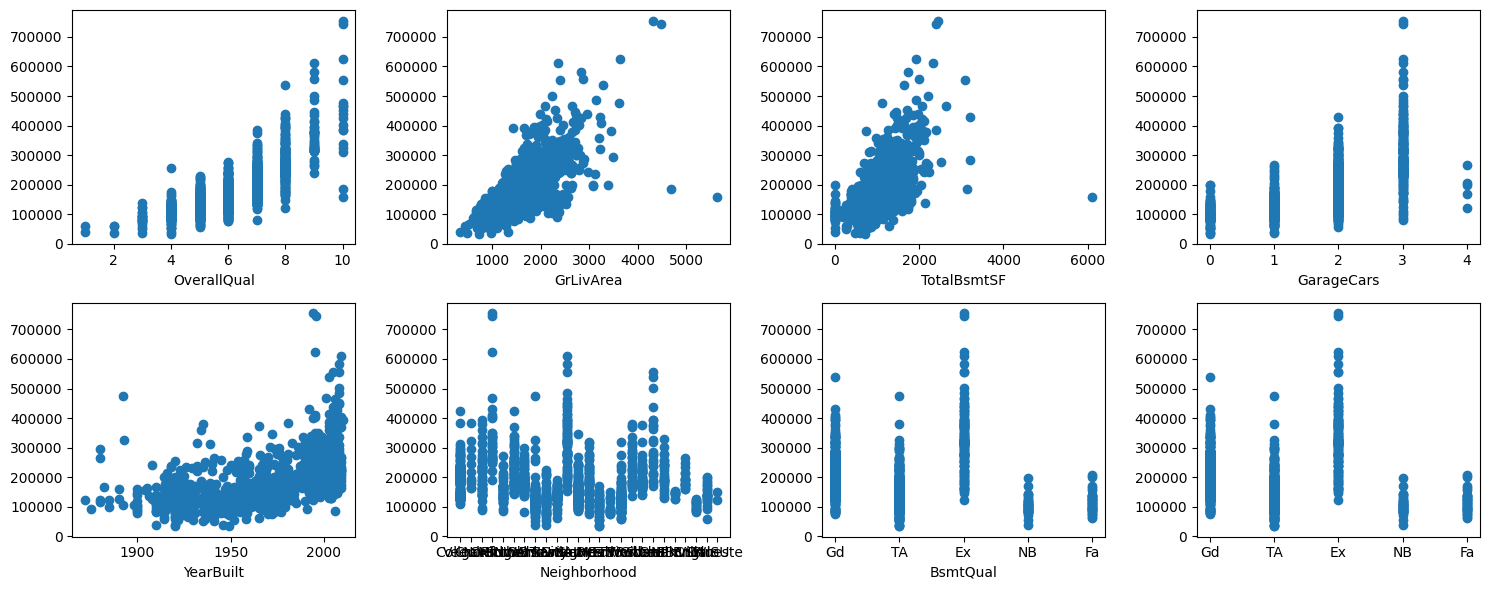

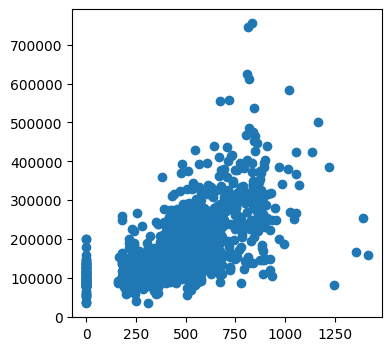

In [50]:
atributos = winner_var_list

def dispersion(dataset, attrs, numcol, numrow):
    fig, axes = plt.subplots(ncols=numcol, nrows=numrow, figsize=(15, 6))
    for i, ax in enumerate(axes.flatten()):
        if i > len(attrs):
            break
        attr = attrs[i]
        if i==7:
            serie = dataset["BsmtQual"].fillna('NB')
            ax.scatter(serie, dataset.SalePrice)
        else:
            ax.scatter(dataset[attr], dataset.SalePrice)
            ax.set_xlabel(attr)

    plt.tight_layout()
    plt.show()
dispersion(df, atributos, 4, 2)
plt.figure(figsize=(4,4))
plt.scatter(df.GarageArea, df.SalePrice)
plt.plot();

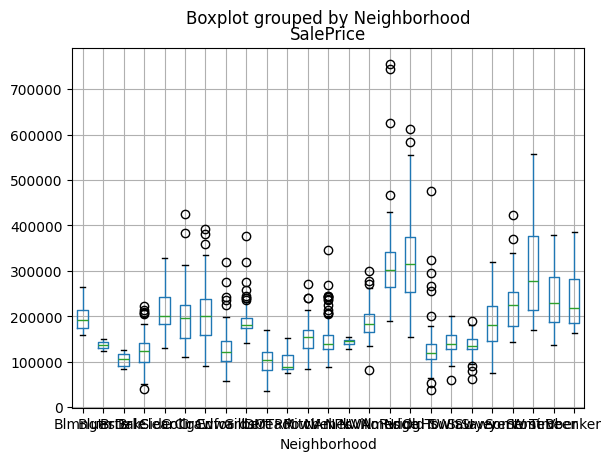

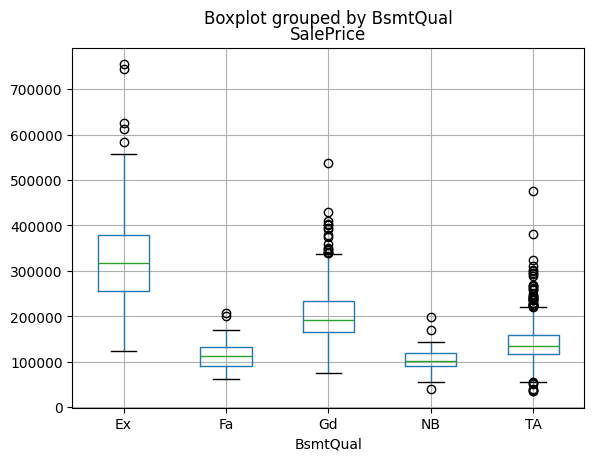

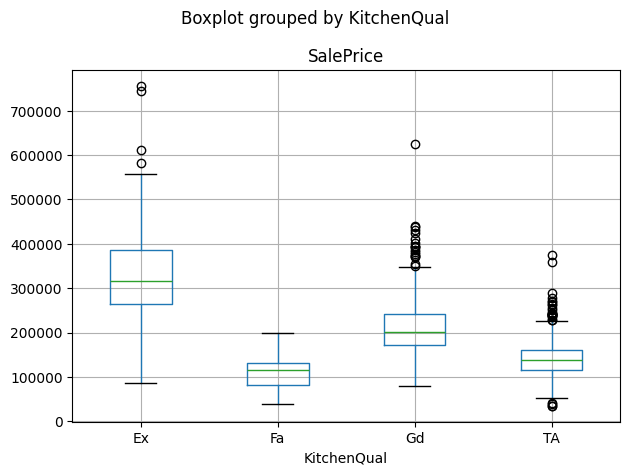

In [51]:
atributos = winner_var_list


def boxplot(dataset, attrs):
    for i in range(0,len(attrs)):
        attr = attrs[i]

        if i==7:
            serie = dataset["BsmtQual"].fillna('NB')
            dataset.boxplot(column="SalePrice", by=attr)
        elif(dataset[attr].dtype=="str"):
            dataset.boxplot(column="SalePrice", by=attr)
            
            

    plt.tight_layout()
    plt.show()
boxplot(df, atributos)

# FASE B - Limpieza y preprocesado

## Tratamiento de datos vacíos
##### Diego:
En su momento sacamos como debemos cambiar estas variables (clica dos veces para ver mejor):
LotFrontage    259
MasVnrType     872
MasVnrArea       8
Electrical       1
GarageYrBlt     81
dtype: int64

Sobre este tema podríamos debatir lo que quisiéramos. Para empezar lo he hecho así, también se menciona (2) utilizar SimpleImputer (from sklearn.impute import SimpleImputer) como una forma eficiente pero, como no sé cómo funciona, prefiero como está hecho por ahora.

Posteriormente decidimos sobre las variables con valores vacíos sin singificado: 
- Las variables numéricas => Imputamos la mediana (recomendación Nando)
- Las variables categóricas => 
    1. MasVnrType (588 no vacíos sobre 1460) => Nos cargamos la columna
    2. Electrical (1459 no vacíos sobre 1460) => Eliminamos la fila (si queremos imputarla por KNN ver (3))

In [52]:
def atributos_con_vacios(datafr):
    serie = datafr.isna().sum()
    print("\nLos atributos con valores vacíos en el dataframe son:\n", serie[serie>0])

In [53]:
df_imputation = df.copy()
atributos_vacio_sin_signficado = ["LotFrontage", "MasVnrType", "MasVnrArea", "Electrical", "GarageYrBlt"] # Lista de atributos donde cambiar los valores vacíos por la mediana
atributos_vacio_con_significado = ["Alley", "BsmtQual", "BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond","PoolQC","Fence","MiscFeature"]
if((df[atributos_vacio_con_significado].dtypes=="str").all()):
    print("Todas las variables cuyos valores vacíos TIENEN SIGNIFICADO son variables categóricas\n")


atributos = np.concat((atributos_vacio_sin_signficado, atributos_vacio_con_significado))
# print("Los tipos de cada atributo son: \n", df[atributos].dtypes)
i = 0
for attr in atributos:
    if((df[attr].dtypes=="str") & (attr != "Electrical")):
        # Los valores vacíos con significado quieren decir que no hay, por eso lo cambiamos por "None". Kaggle (1)
        df_imputation[attr] = df[attr].fillna("None")
        # Si no tiene signficado, solo hay Electrical y MasVnrType
        if(attr=="MasVnrType"):
            # Eliminamos columna MasVnrType
            df_imputation.drop(columns=attr, inplace=True)
    elif(attr == "Electrical"):
        pass
    else:
        # Tal y como dice Nando, lo mejor es la mediana para evitar problemas con outliers
        df_imputation[attr] =df[attr].fillna(df[attr].median())
    i = i+1


atributos_con_vacios(df_imputation)

# Eliminamos la fila con valor vacío en Electrical
df_imputation = df_imputation.dropna()

atributos_con_vacios(df_imputation)


Todas las variables cuyos valores vacíos TIENEN SIGNIFICADO son variables categóricas


Los atributos con valores vacíos en el dataframe son:
 Electrical    1
dtype: int64

Los atributos con valores vacíos en el dataframe son:
 Series([], dtype: int64)


In [54]:
clean_df = df_imputation.copy()

## Eliminación de outliers
Antes de eliminar volvemos a hacer un análisis con los atributos con valores imputados.

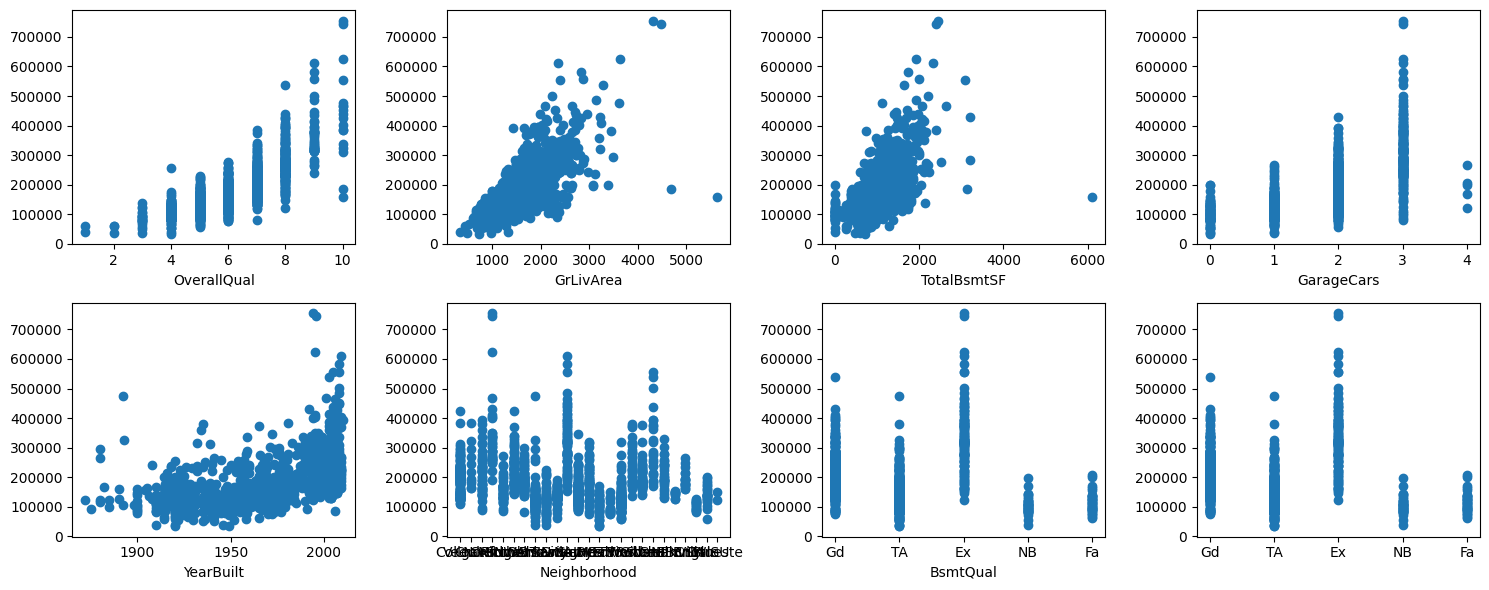

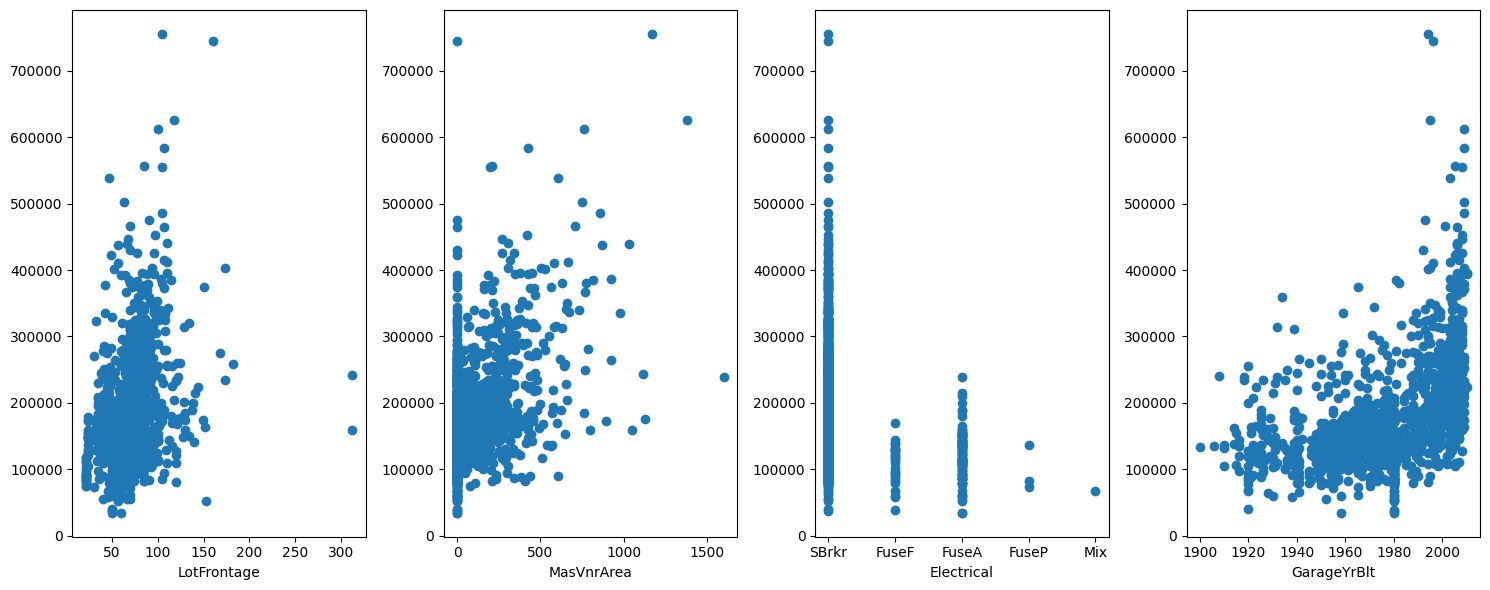

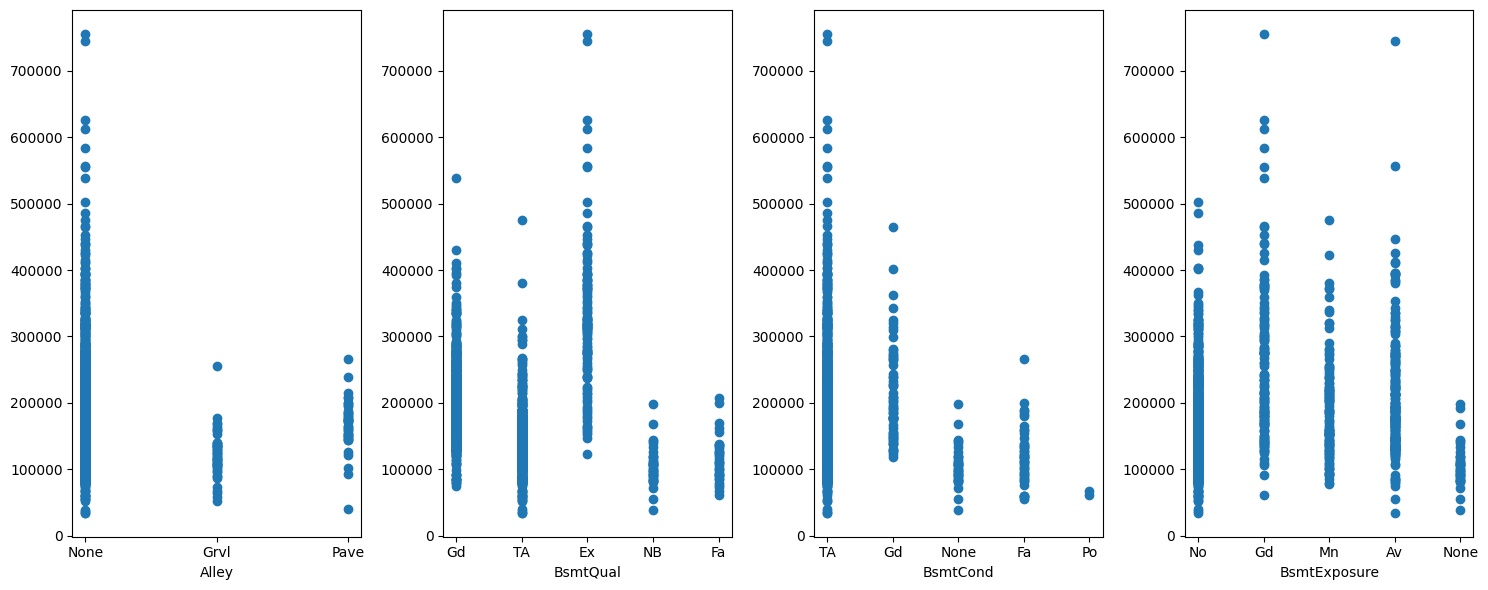

In [55]:
atributos_vacio_sin_signficado = ["LotFrontage", "MasVnrArea", "Electrical", "GarageYrBlt"] # Lista de atributos donde cambiar los valores vacíos por la mediana
atributos_vacio_con_significado = ["Alley", "BsmtQual", "BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond","PoolQC","Fence","MiscFeature"]
dispersion(df_imputation, winner_var_list, 4,2)
dispersion(df_imputation, atributos_vacio_sin_signficado, 4, 1)
dispersion(df_imputation, atributos_vacio_con_significado, 4, 1)

In [56]:
# Yo eliminaría más puntos de GrLivArea, no solo los 2 naranjas (DIEGO: Toda la razón, en otros cuadernos también lo hacen)
clean_df = clean_df[clean_df["TotalBsmtSF"] < 5000]
clean_df = clean_df[clean_df["1stFlrSF"] < 4000]
clean_df = clean_df[clean_df["GrLivArea"] < 4000]
clean_df = clean_df[clean_df["GarageArea"] < 1240]
clean_df = clean_df[clean_df["LotFrontage"] < 300]
clean_df = clean_df[clean_df["MasVnrArea"]<=1300]

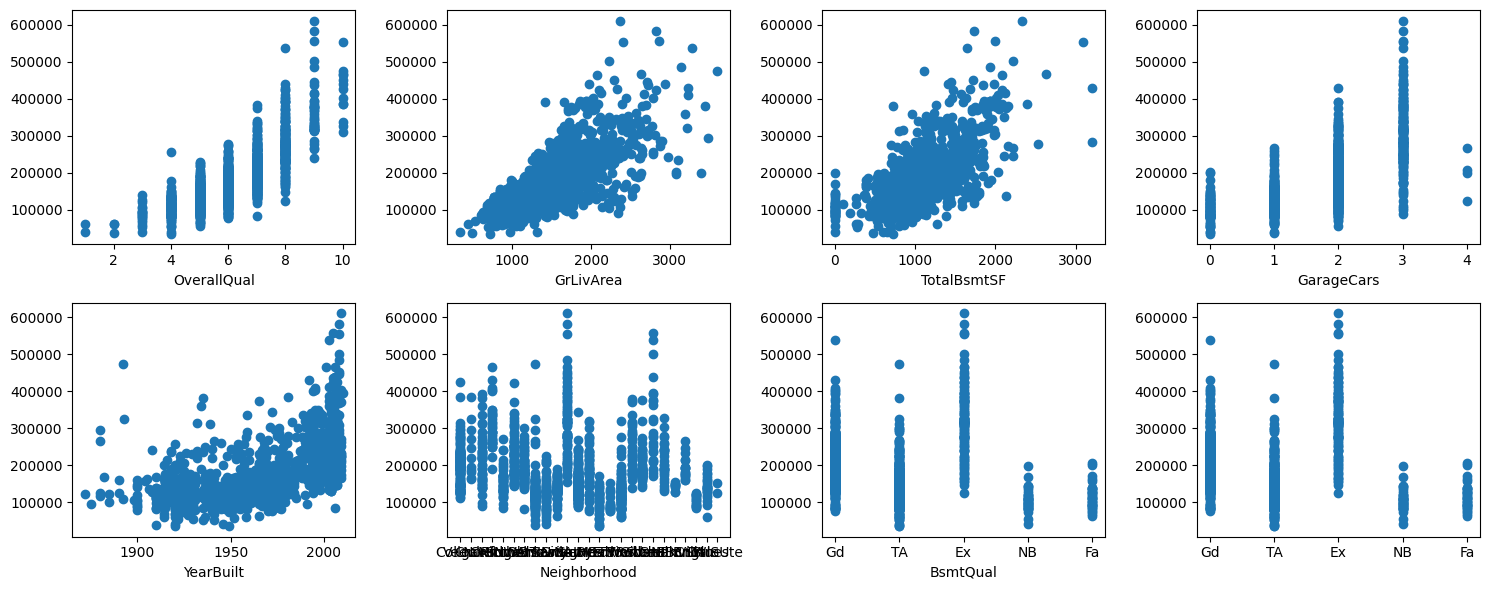

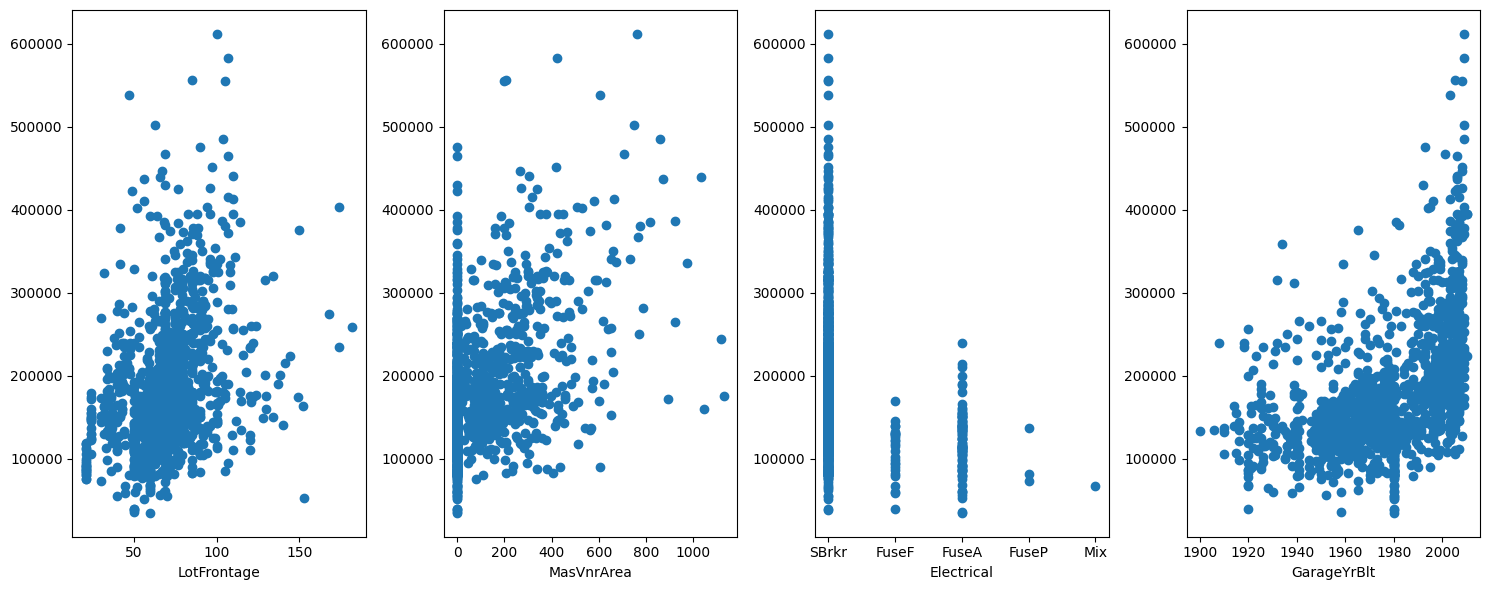

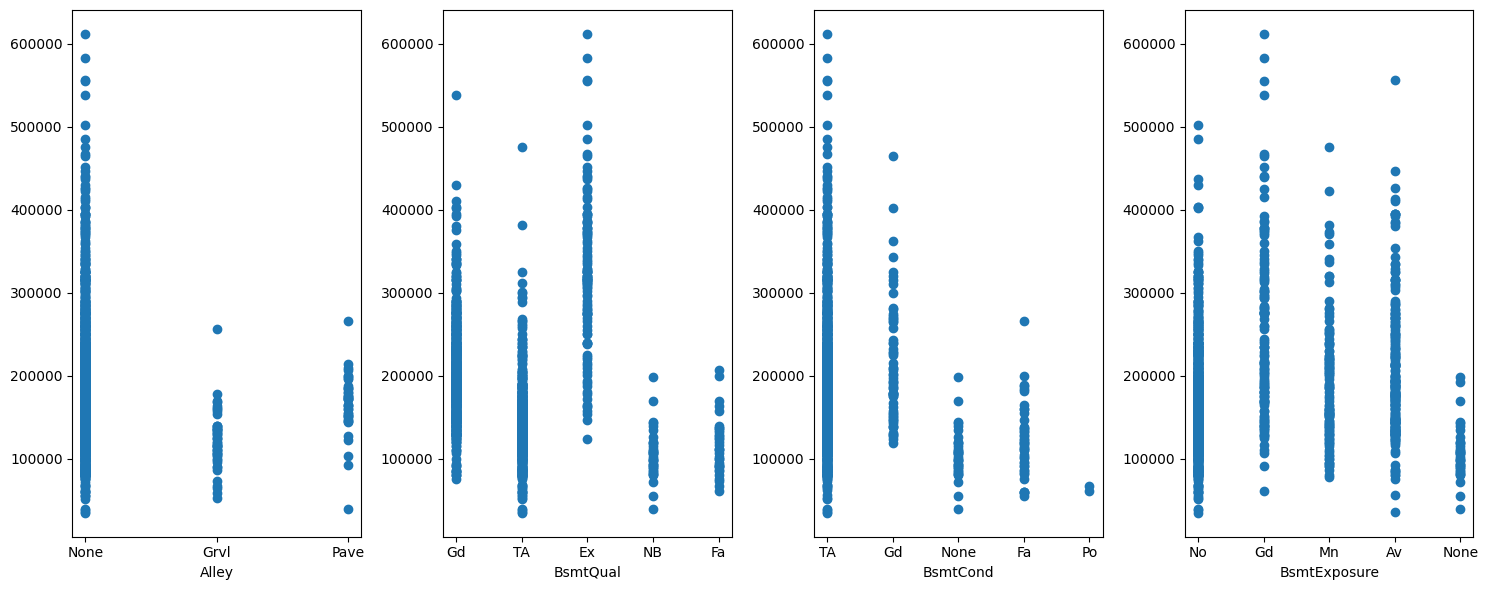

In [57]:
atributos_vacio_sin_signficado = ["LotFrontage", "MasVnrArea", "Electrical", "GarageYrBlt"] # Lista de atributos donde cambiar los valores vacíos por la mediana
atributos_vacio_con_significado = ["Alley", "BsmtQual", "BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond","PoolQC","Fence","MiscFeature"]
dispersion(clean_df, winner_var_list, 4,2)
dispersion(clean_df, atributos_vacio_sin_signficado, 4, 1)
dispersion(clean_df, atributos_vacio_con_significado, 4, 1)




## Normalización de variables

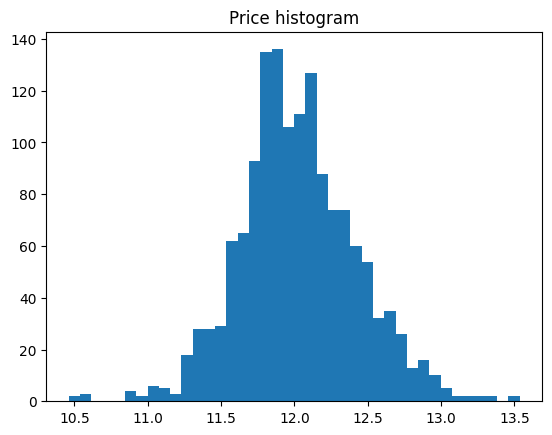

In [58]:
# Normalización de la variable objetivo "SalePrice" PENDIENTE
plt.hist(np.log1p(dataset_df["SalePrice"]), bins = 40)
plt.title("Price histogram")
plt.show()

In [59]:
clean_df["TotalBsmtSF"] = np.sqrt(clean_df.TotalBsmtSF)
clean_df["1stFlrSF"] = np.log(clean_df["1stFlrSF"])
clean_df["GrLivArea"] = np.log(clean_df.GrLivArea)
clean_df["SalePrice"] = np.log1p(clean_df["SalePrice"])

# FASE C - Ingeniería de características
Nando propone cuatro (TotalSF, Age, indicadores binarios y variables de interacción). En clase también propuso agrupar las vivendas por barrios.

In [ ]:
# Áreas total
clean_df["TotalSF"] = clean_df["GrLivArea"] + clean_df["TotalBsmtSF"] + clean_df["GarageArea"]

# Edad de la casa
clean_df["Age"] = clean_df["YrSold"] - clean_df["YearBuilt"]
clean_df["AgeRemod"] = clean_df["YrSold"] - clean_df["YearRemodAdd"]

# Indicadores binarios (GEMINI)
clean_df["HasPool"] = clean_df["PoolArea"].apply(lambda x: 1 if x > 0 else 0)
clean_df["Has2ndFloor"] = clean_df["2ndFlrSF"].apply(lambda x: 1 if x > 0 else 0)
clean_df["IsRemodeled"] = (clean_df["YearRemodAdd"] != clean_df["YearBuilt"]).astype(int)
clean_df["HasGarage"] = clean_df["GarageArea"].apply(lambda x: 1 if x > 0 else 0)

# Variables de interacción
clean_df["Qual_GrLivArea"] = clean_df["OverallQual"] * clean_df["GrLivArea"]

# Verificación de datos nulos
print(clean_df["TotalSF"].notna().all(), clean_df["Age"].notna().all(), "=> True si no hay valores nulos")
print()

# Correlación
corr_matrix = clean_df[["SalePrice", "TotalSF", "Age"]].corr()
print("Índice de correlación con SalePrice\n", corr_matrix["SalePrice"][1:])

True True => True si no hay valores nulos

Índice de correlación con SalePrice
 TotalSF    0.680012
Age       -0.589671
Name: SalePrice, dtype: float64


# FASE D - Modelado
### Tenemos los modelos en la diapositiva 101 de la asignatura

In [113]:
def regression_report(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:>12s}:  MSE={mse:6.4f}   RMSE={rmse:5.10f}   MAE={mae:5.2f}   R²={r2:.3f}")
    return rmse



In [132]:
model = DecisionTreeRegressor(criterion = "squared_error", max_depth=10, random_state=RANDOM_STATE)

#Prepare data

X = clean_df[clean_df.columns[clean_df.dtypes=="float64"]] # Cogemos solo las variables numéricas
Y = clean_df["SalePrice"]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=RANDOM_STATE)

#Train and predict
model.fit(X_train,Y_train)
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
print(rmse)


rmse_train = regression_report(Y_train, Y_train_pred, "TRAIN")
rmse_test = regression_report(Y_test,  Y_test_pred,  "TEST")

F = rmse_train / rmse_test
df1 = len(X_train)
df2 = len(X_test)
p = f.cdf(F, df1, df2) # percentil para el ratio
print("F= ", p*100)

0.037281331321574254
       TRAIN:  MSE=0.0000   RMSE=0.0000928682   MAE= 0.00   R²=1.000
        TEST:  MSE=0.0014   RMSE=0.0372813313   MAE= 0.01   R²=0.991
F=  0.0


### GridSearch con árbol de decisión de regresión

In [134]:
model = DecisionTreeRegressor(criterion = "squared_error", max_depth=10)


#Prepare data
test = pd.read_csv("data/test.csv")

X = clean_df[clean_df.columns[clean_df.dtypes=="float64"]].drop(columns="SalePrice") # Cogemos solo las variables numéricas
Y = clean_df["SalePrice"]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=RANDOM_STATE)

#Train and predict
param_grid = {
    "max_depth": [None, 10, 20]
}
model = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), param_grid, cv=5, scoring= "neg_mean_squared_error", n_jobs=1 ).fit(X_train, Y_train)

def regression_report(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:>12s}:  MSE={mse:6.4f}   RMSE={rmse:5.10f}   MAE={mae:5.2f}   R²={r2:.3f}")
    return rmse

Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)
rmse_train = regression_report(Y_train, Y_train_pred, "TRAIN")
rmse_test = regression_report(Y_test, Y_test_pred, "TRAIN")

       TRAIN:  MSE=0.0065   RMSE=0.0807963878   MAE= 0.05   R²=0.957
       TRAIN:  MSE=0.0454   RMSE=0.2129750588   MAE= 0.15   R²=0.717


### GridSearch con Ridge y Lasso


In [141]:
# Extraído de C03_AutoMPG
ridge_cv = RidgeCV(alphas=np.logspace(-5, 5, 100), cv=5).fit(X_train, Y_train)
lasso_cv = LassoCV(alphas=np.logspace(-5, 5, 100), cv=5,
                   max_iter=20000, random_state=RANDOM_STATE).fit(X_train, Y_train)

print("Test set with tuned alphas:")
for name, model in [("Ridge (tuned)", ridge_cv),
                    ("Lasso (tuned)", lasso_cv)]:
    Y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2   = r2_score(Y_test, Y_pred)
    print(f"  {name:14s}  RMSE={rmse:.3f}   R²={r2:.3f}")

Test set with tuned alphas:
  Ridge (tuned)   RMSE=0.164   R²=0.832
  Lasso (tuned)   RMSE=0.164   R²=0.832


# FASE E - Validación

# FASE F - Envío y posicionamiento

## Bibliografía tú que a mi me da la risa

Kaggle (1): https://www.kaggle.com/code/serigne/stacked-regressions-top-4-on-leaderboard 

Kaggle (2): https://www.kaggle.com/code/dansbecker/handling-missing-values

Kaggle (3): https://www.kaggle.com/discussions/questions-and-answers/153147

### Cosas pendientes

Hasta el momento estamos entrenando un modelo con:
- Variables "ganadoras" de Nando
- Variables que contenían valores vacíos

Por ahora (26/05 12:20) tenemos:
- Imputación de todos los valores
- Eliminación de valores anómalos de variables numéricas
- (Carles lo ha hecho pero falta por pegar) Primer modelete

Por lo tanto, los próximos pasos a dar son:
- Eliminación de valores anómalos en variables categóricas
- Fases C, D y E




### Modelo (por ahora)
Tenemos un modelo con características:
"LotFrontage", "Electrical", "GarageYrBlt", "Alley", "BsmtQual", "BsmtCond","BsmtExposure", "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature", "OverallQual", "GrLivArea","TotalBsmtSF" ,"GarageCars" ,"YearBuilt" ,"Neighborhood" ,"BsmtQual", "KitchenQual"